In [7]:
ls

app.py
chennai_2024_clean.csv
City_wise_raw_data_1Day_2024_Chennai_1Day.csv
README.md
Untitled.ipynb


In [4]:
import pandas as pd
import numpy as np

In [16]:
df = pd.read_csv("chennai_2024_clean.csv")

In [17]:
df.head()

,timestamp,pm25_ug_m,pm10_ug_m,no_ug_m,no2_ug_m,nox_ppb,nh3_ug_m,so2_ug_m,co_mg_m,ozone_ug_m,...,mp_xylene_ug_m,at_degc,rh,ws_m_s,wd_deg,rf_mm,tot_rf_mm,sr_w_mt2,bp_mmhg,vws_m_s
0,2024-01-01,59.29,110.75,7.15,18.62,19.56,17.39,14.17,1.33,15.19,...,0.46,26.64,75.55,1.50,156.63,0.00,0.0,114.82,859.84,-0.47
1,2024-01-02,46.35,90.18,7.71,16.56,19.80,16.99,12.66,1.13,15.45,...,0.43,27.09,75.80,1.31,186.39,0.00,0.0,100.81,858.83,-0.48
2,2024-01-03,54.14,106.41,9.39,18.44,22.62,16.91,13.00,1.07,14.55,...,0.52,27.10,79.37,1.21,155.90,0.00,0.0,75.69,857.45,-0.48
3,2024-01-04,47.89,92.73,10.56,21.32,26.41,17.26,13.55,1.19,13.17,...,0.47,27.16,83.49,1.15,175.40,0.01,0.0,80.65,857.29,-0.48
4,2024-01-05,38.64,81.63,8.90,18.12,21.96,18.22,14.00,0.97,13.19,...,0.41,27.44,81.54,1.54,155.04,0.00,0.0,87.78,857.11,-0.46


In [18]:
df2 = pd.read_csv("City_wise_raw_data_1Day_2024_Chennai_1Day.csv")

In [19]:
df2.head()

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,2024-01-01,59.29,110.75,7.15,18.62,19.56,17.39,14.17,1.33,15.19,...,0.46,26.64,75.55,1.50,156.63,0.00,0.0,114.82,859.84,-0.47
1,2024-01-02,46.35,90.18,7.71,16.56,19.80,16.99,12.66,1.13,15.45,...,0.43,27.09,75.80,1.31,186.39,0.00,0.0,100.81,858.83,-0.48
2,2024-01-03,54.14,106.41,9.39,18.44,22.62,16.91,13.00,1.07,14.55,...,0.52,27.10,79.37,1.21,155.90,0.00,0.0,75.69,857.45,-0.48
3,2024-01-04,47.89,92.73,10.56,21.32,26.41,17.26,13.55,1.19,13.17,...,0.47,27.16,83.49,1.15,175.40,0.01,0.0,80.65,857.29,-0.48
4,2024-01-05,38.64,81.63,8.90,18.12,21.96,18.22,14.00,0.97,13.19,...,0.41,27.44,81.54,1.54,155.04,0.00,0.0,87.78,857.11,-0.46


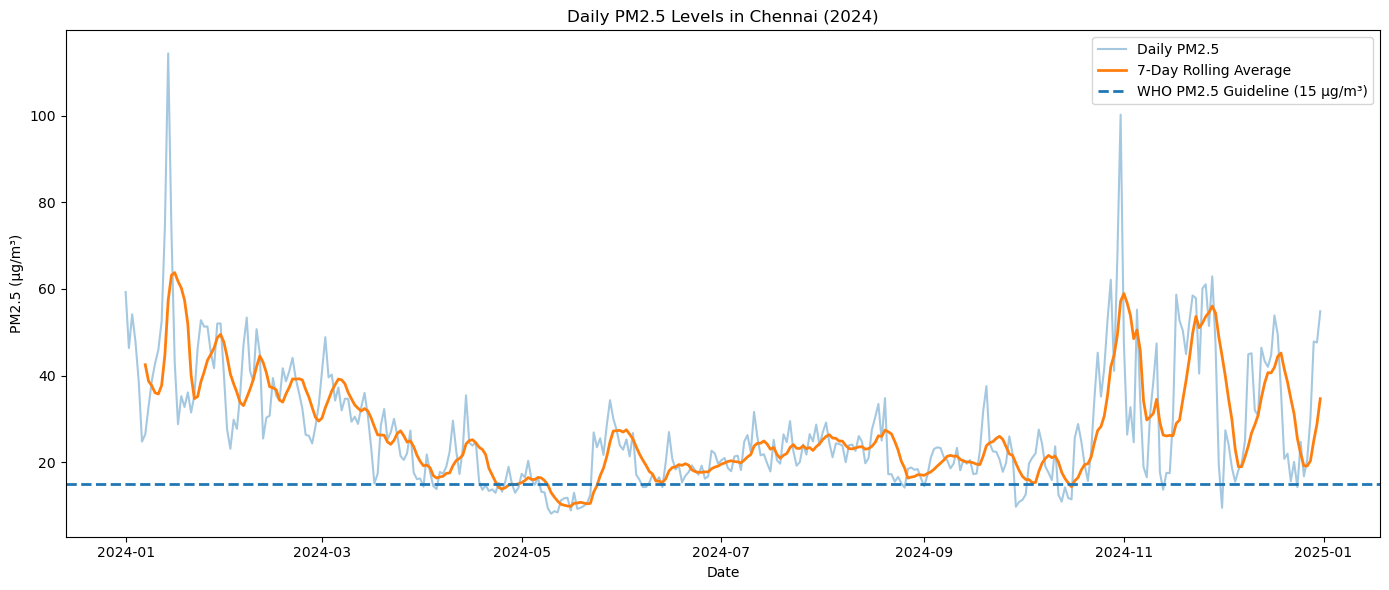

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("chennai_2024_clean.csv")

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by date (important for rolling averages)
df = df.sort_values("timestamp")
df["pm25_7day_avg"] = df["pm25_ug_m"].rolling(window=7).mean()
plt.figure(figsize=(14, 6))

# Daily PM2.5 (light)
plt.plot(
    df["timestamp"],
    df["pm25_ug_m"],
    alpha=0.4,
    label="Daily PM2.5"
)

# 7-day rolling average (bold)
plt.plot(
    df["timestamp"],
    df["pm25_7day_avg"],
    linewidth=2,
    label="7-Day Rolling Average"
)

# Optional: WHO guideline (15 µg/m³)
plt.axhline(
    y=15,
    linestyle="--",
    linewidth=2,
    label="WHO PM2.5 Guideline (15 µg/m³)"
)

plt.title("Daily PM2.5 Levels in Chennai (2024)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


## 

In [28]:
print("Daily PM2.5 concentrations in Chennai during 2024 show substantial variability and frequent exceedance of the WHO guideline. The 7-day rolling average highlights sustained periods of elevated pollution, particularly in the early and late months of the year, indicating prolonged exposure risk rather than isolated pollution events.")

Daily PM2.5 concentrations in Chennai during 2024 show substantial variability and frequent exceedance of the WHO guideline. The 7-day rolling average highlights sustained periods of elevated pollution, particularly in the early and late months of the year, indicating prolonged exposure risk rather than isolated pollution events.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("chennai_2024_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create rain indicator
df["rain_day"] = df["rf_mm"] > 0


<Figure size 800x600 with 0 Axes>

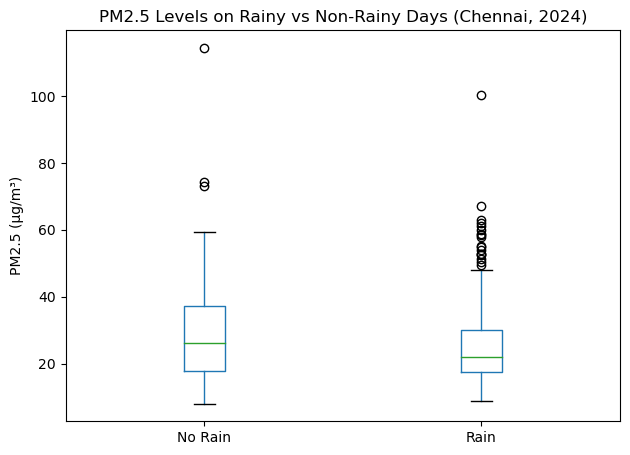

rain_day
False    28.995152
True     26.276368
Name: pm25_ug_m, dtype: float64

In [31]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column="pm25_ug_m",
    by="rain_day",
    grid=False
)

plt.xticks([1, 2], ["No Rain", "Rain"])
plt.title("PM2.5 Levels on Rainy vs Non-Rainy Days (Chennai, 2024)")
plt.suptitle("")  # removes automatic pandas title
plt.xlabel("")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()
df.groupby("rain_day")["pm25_ug_m"].mean()


In [34]:
print("PM2.5 concentrations were modestly lower on rainy days compared to non-rainy days in Chennai during 2024. While rainfall appears to reduce particulate levels through atmospheric washout, median PM2.5 values remained above health-based guidelines on both rainy and non-rainy days, indicating that precipitation alone is insufficient to prevent unhealthy air quality.")

PM2.5 concentrations were modestly lower on rainy days compared to non-rainy days in Chennai during 2024. While rainfall appears to reduce particulate levels through atmospheric washout, median PM2.5 values remained above health-based guidelines on both rainy and non-rainy days, indicating that precipitation alone is insufficient to prevent unhealthy air quality.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("chennai_2024_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])


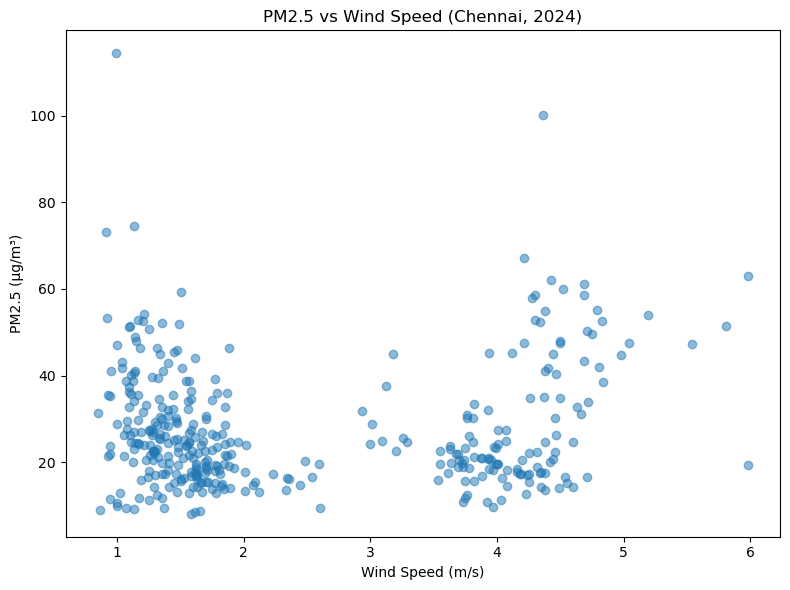

<Figure size 900x600 with 0 Axes>

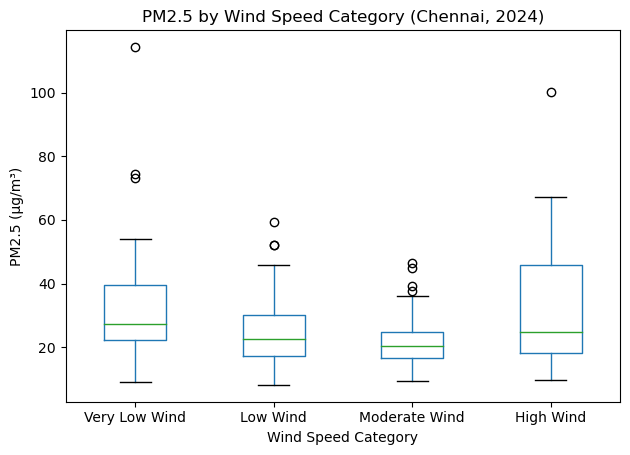

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["ws_m_s"],
    df["pm25_ug_m"],
    alpha=0.5
)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 vs Wind Speed (Chennai, 2024)")
plt.tight_layout()
plt.show()
# Create wind speed quartiles
df["wind_group"] = pd.qcut(df["ws_m_s"], q=4, labels=[
    "Very Low Wind",
    "Low Wind",
    "Moderate Wind",
    "High Wind"
])

# Boxplot by wind group
plt.figure(figsize=(9, 6))
df.boxplot(column="pm25_ug_m", by="wind_group", grid=False)

plt.title("PM2.5 by Wind Speed Category (Chennai, 2024)")
plt.suptitle("")
plt.xlabel("Wind Speed Category")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()



In [38]:
print("PM2.5 concentrations are lowest under moderate wind conditions, while both very low and high wind speeds are associated with higher pollution levels, suggesting a non-linear relationship between wind and air quality.")

PM2.5 concentrations are lowest under moderate wind conditions, while both very low and high wind speeds are associated with higher pollution levels, suggesting a non-linear relationship between wind and air quality.


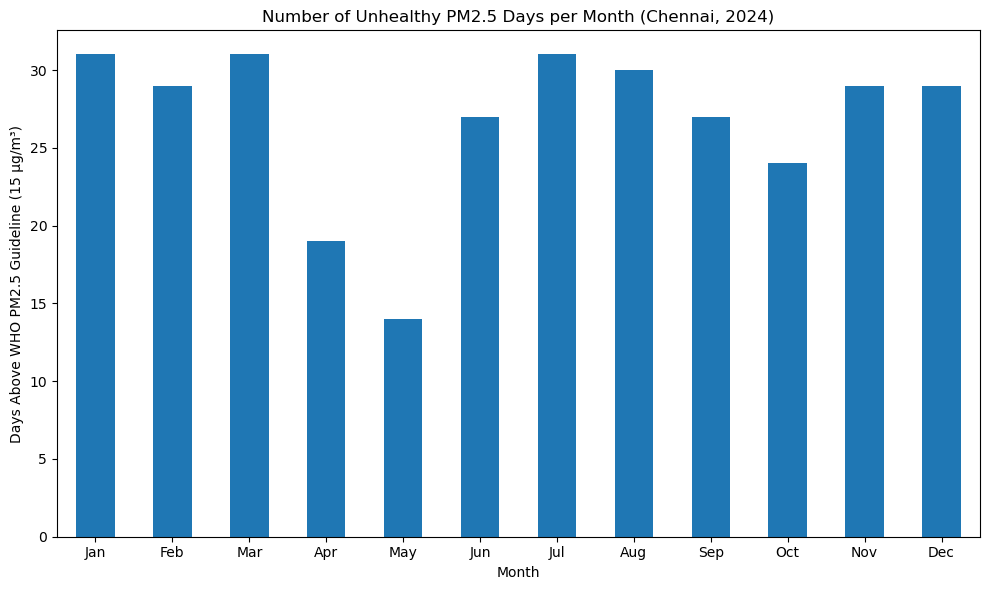

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("chennai_2024_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Define unhealthy days
WHO_PM25 = 15
df["unhealthy"] = df["pm25_ug_m"] > WHO_PM25

# Extract month
df["month"] = df["timestamp"].dt.month

unhealthy_by_month = (
    df.groupby("month")["unhealthy"]
    .sum()
)

plt.figure(figsize=(10, 6))

unhealthy_by_month.plot(kind="bar")

plt.title("Number of Unhealthy PM2.5 Days per Month (Chennai, 2024)")
plt.xlabel("Month")
plt.ylabel("Days Above WHO PM2.5 Guideline (15 µg/m³)")
plt.xticks(
    ticks=range(12),
    labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
    rotation=0
)
plt.tight_layout()
plt.show()



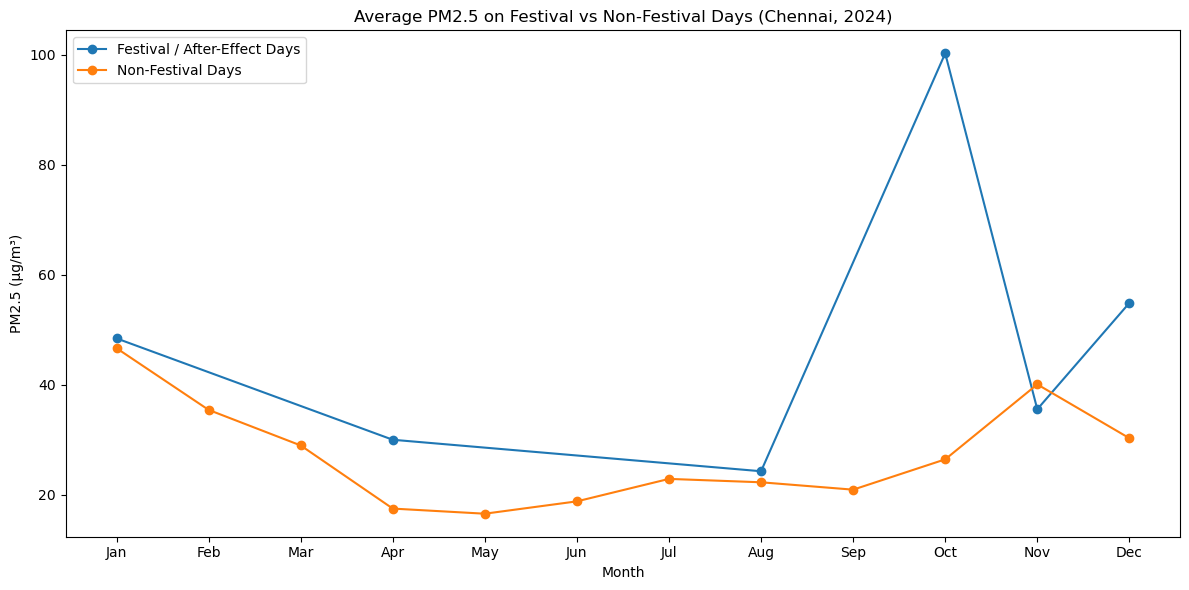

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("chennai_2024_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

festival_windows = [
    ("2024-01-26", "2024-01-27"),  # Republic Day
    ("2024-04-14", "2024-04-15"),  # Tamil New Year
    ("2024-08-15", "2024-08-16"),  # Independence Day
    ("2024-10-31", "2024-11-03"),  # Diwali + after-effects
    ("2024-12-31", "2025-01-01"),  # New Year
]

df["is_festival"] = False
for start, end in festival_windows:
    df.loc[
        (df["timestamp"] >= start) & (df["timestamp"] <= end),
        "is_festival"
    ] = True

df["month"] = df["timestamp"].dt.month
avg_pm25 = (
    df.groupby(["month", "is_festival"])["pm25_ug_m"]
      .mean()
      .reset_index()
)

avg_pm25["Period"] = avg_pm25["is_festival"].map({
    True: "Festival / After-Effect Days",
    False: "Non-Festival Days"
})
plt.figure(figsize=(12, 6))

for label, group in avg_pm25.groupby("Period"):
    plt.plot(
        group["month"],
        group["pm25_ug_m"],
        marker="o",
        label=label
    )

plt.xticks(
    ticks=range(1, 13),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.title("Average PM2.5 on Festival vs Non-Festival Days (Chennai, 2024)")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
print("It is quite ecident the impact festivals have on the city. As we can see, Diwali in October has devastating effect on the PM2.5 levels.")

It is quite ecident the impact festivals have on the city. As we can see, Diwali in October has devastating effect on the PM2.5 levels.


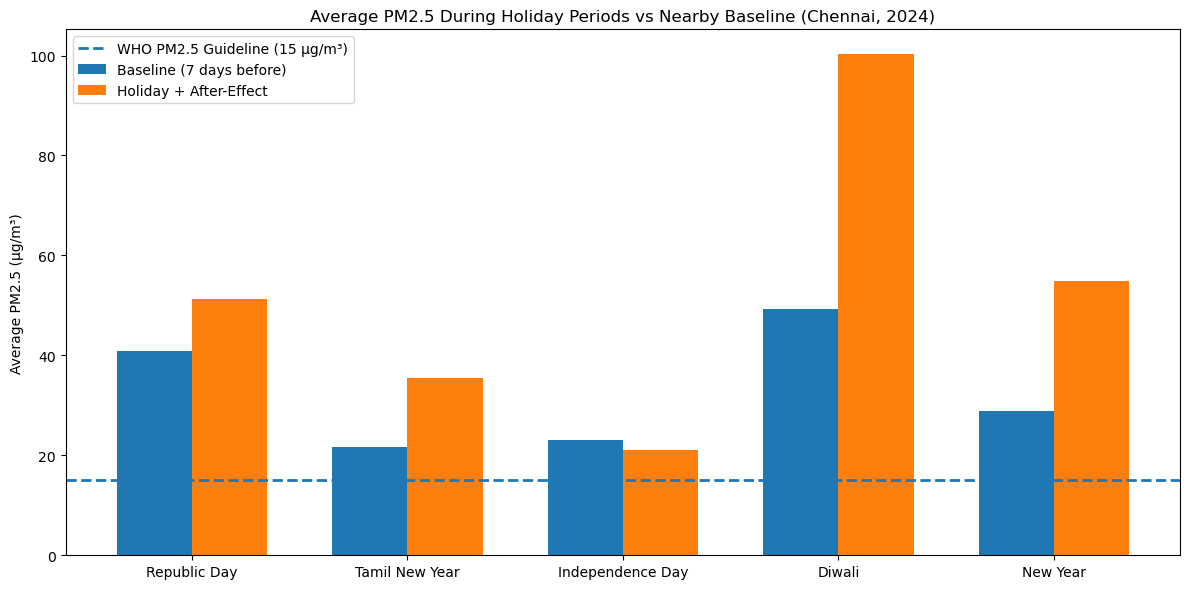

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("chennai_2024_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

holidays = {
    "Republic Day": "2024-01-26",
    "Tamil New Year": "2024-04-14",
    "Independence Day": "2024-08-15",
    "Diwali": "2024-10-31",
    "New Year": "2024-12-31",
}

BASELINE_DAYS = 7
AFTER_DAYS = 0

labels = []
baseline_means = []
holiday_means = []

for name, date_str in holidays.items():
    d = pd.to_datetime(date_str)

    baseline = df[
        (df["timestamp"] >= d - pd.Timedelta(days=BASELINE_DAYS)) &
        (df["timestamp"] < d)
    ]["pm25_ug_m"]

    holiday = df[
        (df["timestamp"] >= d) &
        (df["timestamp"] <= d + pd.Timedelta(days=AFTER_DAYS))
    ]["pm25_ug_m"]

    if len(baseline) > 0 and len(holiday) > 0:
        labels.append(name)
        baseline_means.append(baseline.mean())
        holiday_means.append(holiday.mean())

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, baseline_means, width, label="Baseline (7 days before)")
plt.bar(x + width/2, holiday_means, width, label="Holiday + After-Effect")
plt.axhline(
    y=15,
    linestyle="--",
    linewidth=2,
    label="WHO PM2.5 Guideline (15 µg/m³)"
)

plt.xticks(x, labels)
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("Average PM2.5 During Holiday Periods vs Nearby Baseline (Chennai, 2024)")
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
print("the following graph shows more clearly the pollution effects these festivals have")

the following graph shows more clearly the pollution effects these festivals have
